## Preprocessing


In [2]:
import pandas as pd
import numpy as np

# =============================================================================
# MODULO DATA ENGINEERING: PREPARAZIONE DATASET CSP - MUMBAI CON AREE
# =============================================================================
print("=" * 70)
print(" 🚀 DATA ENGINEERING: GENERAZIONE DATASET CSP (CON AREE GEOGRAFICHE)")
print("=" * 70)

# ─────────────────────────────────────────────
# 1. CARICAMENTO E FILTRO GEOGRAFICO
# ─────────────────────────────────────────────
try:
    df = pd.read_csv("../Preprocessing/amazon_delivery_final.csv")
    print(f"\n[1] Dataset originale caricato: {len(df)} righe.")
except FileNotFoundError:
    raise FileNotFoundError("Il file dataset non è stato trovato. Verifica il percorso.")

# Filtro geografico stretto (Bounding Box per Mumbai)
mumbai_mask = (
    (df["Store_Latitude"].between(18.9, 19.3)) &
    (df["Store_Longitude"].between(72.7, 73.0))
)
df_mumbai = df[mumbai_mask].copy().reset_index(drop=True)
print(f"    Righe filtrate nell'area di Mumbai: {len(df_mumbai)}")

if len(df_mumbai) < 60:
    raise ValueError("Dati insufficienti a Mumbai per estrarre 30 ordini e gli agenti necessari.")

# ─────────────────────────────────────────────
# 2. TRASFORMAZIONE DATI (KNOWLEDGE NORMALIZATION)
# ─────────────────────────────────────────────
print("\n[2] Normalizzazione della Conoscenza: De-standardizzazione Rating...")

z_min = df_mumbai["Agent_Rating"].min()
z_max = df_mumbai["Agent_Rating"].max()

# Applicazione della formula: Rating = ((Z - Zmin) / (Zmax - Zmin)) * 4 + 1
df_mumbai["Agent_Rating"] = ((df_mumbai["Agent_Rating"] - z_min) / (z_max - z_min)) * 4.0 + 1.0
df_mumbai["Agent_Rating"] = df_mumbai["Agent_Rating"].round(1)

print(f"    Rating scalati nel range [1.0 - 5.0]. Media attuale: {df_mumbai['Agent_Rating'].mean():.2f}")

# ─────────────────────────────────────────────
# 3. SELEZIONE VARIABILI CSP (30 ORDINI)
# ─────────────────────────────────────────────
print("\n[3] Estrazione delle Variabili (Ordini) con info Area...")
np.random.seed(42)

# Pool separati per garantire i vincoli minimi
home_pool = df_mumbai[df_mumbai["Category_Home"] == 1]
elec_pool = df_mumbai[df_mumbai["Category_Electronics"] == 1]

# Estrazione vincolata
sample_home = home_pool.sample(n=min(6, len(home_pool)), random_state=42)
sample_elec = elec_pool.drop(index=sample_home.index, errors="ignore")
sample_elec = sample_elec.sample(n=min(6, len(sample_elec)), random_state=42)

# Completamento fino a 30 ordini
used_order_indices = set(sample_home.index) | set(sample_elec.index)
remaining_orders = df_mumbai.drop(index=list(used_order_indices))
needed = 30 - len(sample_home) - len(sample_elec)
sample_other = remaining_orders.sample(n=needed, random_state=42)

# Creazione blocco Ordini
orders = pd.concat([sample_home, sample_elec, sample_other]).reset_index(drop=True)
orders["Record_Type"] = "ORDER"
orders["Agent_ID"] = np.nan

if "Order_ID" not in orders.columns:
    orders["Order_ID"] = [f"ORD_{i+1:03d}" for i in range(len(orders))]

used_order_indices.update(sample_other.index)
print(f"    Ordini estratti: {len(orders)} (di cui {len(sample_home)} Home, {len(sample_elec)} Electronics)")

# ─────────────────────────────────────────────
# 4. SELEZIONE DOMINIO CSP (12 AGENTI) CON INFO AREA
# ─────────────────────────────────────────────
print("\n[4] Configurazione del Dominio (Agenti) con info Area...")

# Pool agenti (escludendo gli ordini)
agent_pool = df_mumbai.drop(index=list(used_order_indices)).copy()

# Requisiti: 6 Van e 6 Moto
van_agents = agent_pool[agent_pool["Vehicle_van"] == 1].sample(n=6, random_state=42)
moto_pool  = agent_pool.drop(index=van_agents.index, errors="ignore")
moto_agents = moto_pool[moto_pool["Vehicle_motorcycle"] == 1].sample(n=6, random_state=42)

agents = pd.concat([van_agents, moto_agents])

# Assicuriamo che almeno 5 abbiano rating > 3.8
high_rating_count = (agents["Agent_Rating"] > 3.8).sum()
if high_rating_count < 5:
    needed_high = 5 - high_rating_count
    replacements = agent_pool.drop(index=agents.index, errors="ignore")
    replacements = replacements[replacements["Agent_Rating"] > 3.8].head(needed_high)
    
    if not replacements.empty:
        agents = agents.sort_values("Agent_Rating").iloc[len(replacements):]
        agents = pd.concat([agents, replacements])

agents = agents.reset_index(drop=True)
agents["Agent_ID"] = [f"Agente_{i+1}" for i in range(len(agents))]
agents["Record_Type"] = "AGENT"
agents["Order_ID"] = np.nan

print(f"    Agenti estratti: {len(agents)} (Van: {agents['Vehicle_van'].sum()}, Moto: {agents['Vehicle_motorcycle'].sum()})")
print(f"    Agenti con Rating > 3.8: {(agents['Agent_Rating'] > 3.8).sum()}")

# ─────────────────────────────────────────────
# 5. ESPORTAZIONE E PULIZIA
# ─────────────────────────────────────────────
print("\n[5] Pulizia colonne ed Esportazione...")

# Definizione e ordine delle colonne finali (Schema Target ESPANSO CON AREE)
COLUMNS = [
    "Order_ID",
    "Agent_ID",
    "Record_Type",
    "Agent_Rating",
    "Vehicle_motorcycle",
    "Vehicle_van",
    "Category_Home",
    "Category_Electronics",
    "Area_Urban",
    "Area_Metropolitian",
    "Area_Semi-Urban"
]

# Concateniamo con gli Agenti in testa
final_df = pd.concat([agents, orders], ignore_index=True)

# Forziamo eventuali colonne mancanti a NaN e applichiamo lo schema
for col in COLUMNS:
    if col not in final_df.columns:
        final_df[col] = np.nan
final_df = final_df[COLUMNS]

# Pulizia logica: per gli ordini rimuoviamo le info esclusive degli agenti, 
# TRANNE le info di Area, che servono a ENTRAMBI!
final_df.loc[final_df["Record_Type"] == "ORDER", ["Vehicle_motorcycle", "Vehicle_van", "Agent_Rating"]] = np.nan

# Pulizia logica: per gli agenti rimuoviamo le info esclusive degli ordini
final_df.loc[final_df["Record_Type"] == "AGENT", ["Category_Home", "Category_Electronics"]] = np.nan

output_path = "csp_mumbai_espanso.csv"
final_df.to_csv(output_path, index=False)
print(f"    ✅ Dataset salvato con successo in: {output_path}")

# ─────────────────────────────────────────────
# 6. VERIFICA FINALE (OUTPUT RICHIESTO)
# ─────────────────────────────────────────────
print("\n" + "=" * 70)
print(" 📊 VERIFICA COLONNE AREA")
print("=" * 70)
print("Prime 3 righe (AGENTI):")
print(final_df[final_df["Record_Type"] == "AGENT"][["Agent_ID", "Area_Urban", "Area_Metropolitian", "Area_Semi-Urban"]].head(3).to_string(index=False))

print("\nPrime 3 righe (ORDINI):")
print(final_df[final_df["Record_Type"] == "ORDER"][["Order_ID", "Area_Urban", "Area_Metropolitian", "Area_Semi-Urban"]].head(3).to_string(index=False))
print("=" * 70)

 🚀 DATA ENGINEERING: GENERAZIONE DATASET CSP (CON AREE GEOGRAFICHE)

[1] Dataset originale caricato: 39997 righe.
    Righe filtrate nell'area di Mumbai: 3037

[2] Normalizzazione della Conoscenza: De-standardizzazione Rating...
    Rating scalati nel range [1.0 - 5.0]. Media attuale: 4.39

[3] Estrazione delle Variabili (Ordini) con info Area...
    Ordini estratti: 30 (di cui 6 Home, 6 Electronics)

[4] Configurazione del Dominio (Agenti) con info Area...
    Agenti estratti: 12 (Van: 6, Moto: 6)
    Agenti con Rating > 3.8: 11

[5] Pulizia colonne ed Esportazione...
    ✅ Dataset salvato con successo in: csp_mumbai_espanso.csv

 📊 VERIFICA COLONNE AREA
Prime 3 righe (AGENTI):
Agent_ID  Area_Urban  Area_Metropolitian  Area_Semi-Urban
Agente_1           0                   1                0
Agente_2           0                   1                0
Agente_3           0                   1                0

Prime 3 righe (ORDINI):
     Order_ID  Area_Urban  Area_Metropolitian  Area_Sem

## Script Finale Comparazione Algoritmi

 🚀 CSP BENCHMARK: CONFRONTO ALGORITMI DI ASSEGNAZIONE LOGISTICA
[1] Caricamento e decodifica del dataset...
    Agenti disponibili (Domini)    : 12
    Ordini da assegnare (Variabili): 30

[2] Avvio dell'algoritmo IBI (Min-Conflicts)...
    ✅ Esecuzione terminata in 0.0884s
    📉 Conflitti Iniziali : 15
    📉 Conflitti Finali   : 4
    🔄 Iterazioni totali  : 1500

[3] Generazione Grafico Reale (Matplotlib)...


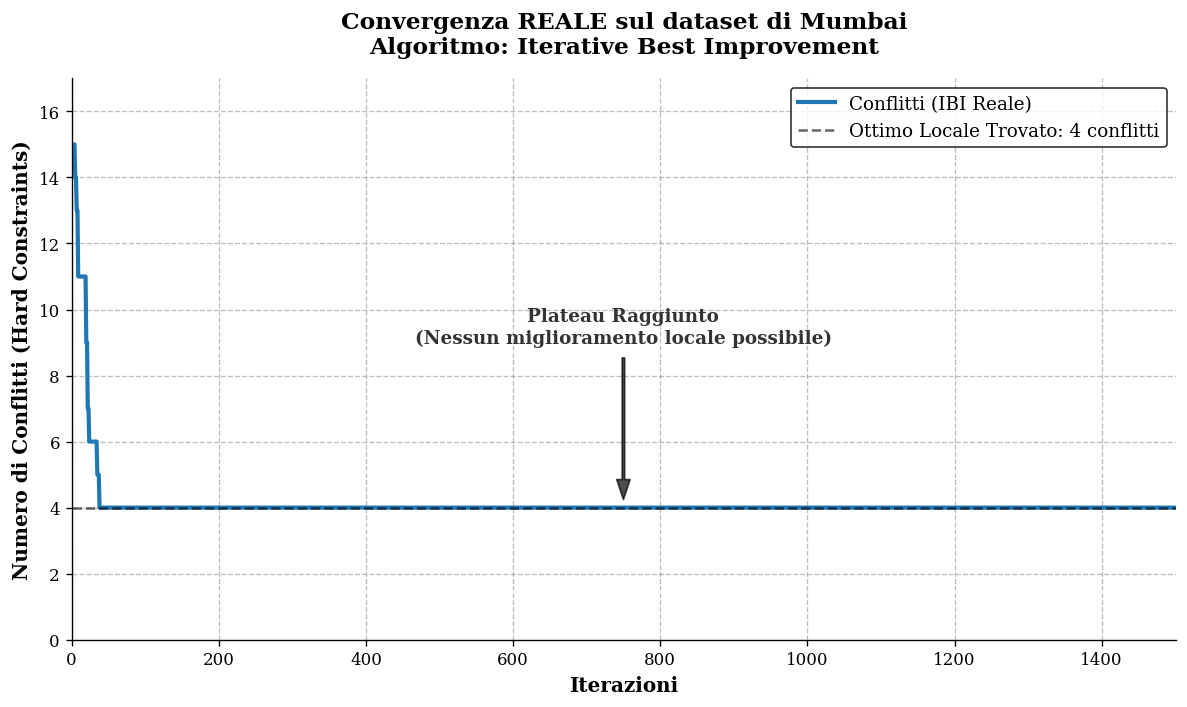


🎉 Grafico pronto! Lo script ha plottato i dati esatti passati dal tuo algoritmo IBI.

[2] Avvio dei motori di ricerca CSP...

 ⚙️  Esecuzione Backtracking Search (Potrebbe impiegare 10 secondi)...
    [!] Timeout Backtracking raggiunto (10.0s). Spazio di ricerca troppo vasto.
 ⚙️  Esecuzione Simulated Annealing...
 ⚙️  Esecuzione Min-Conflicts...

[3] Risultati Finali...

                   TABELLA DI CONFRONTO FINALE ALGORITMI CSP                    
                Algoritmo Soluzione Trovata Conflitti Residui  Nodi Esplorati Tempo (s)
Backtracking (DFS Esatto)           Fallito               N/A          256265  10.00004
      Simulated Annealing        Sub-ottima                 4            2500   0.01151
            Min-Conflicts        Sub-ottima                 4            1000   0.05664

[4] Generazione Grafico Accademico del Simulated Annealing...


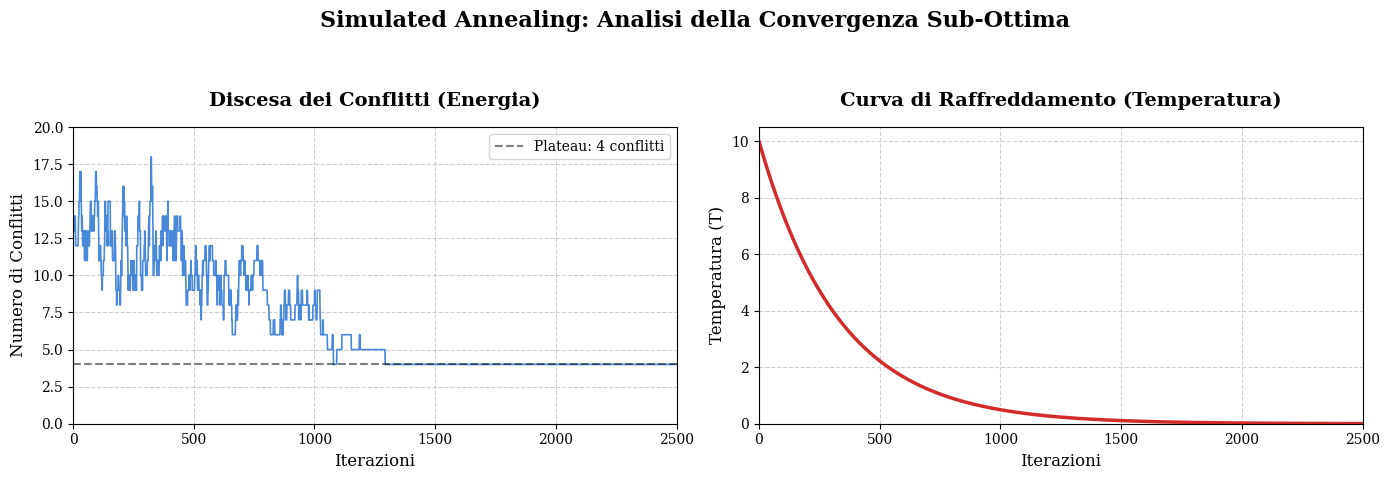

    ✅ Grafico generato con successo!


In [5]:
import pandas as pd
import random
import time
import math
import matplotlib.pyplot as plt

# =============================================================================
# BENCHMARK CSP E ANALISI GRAFICA DEL SIMULATED ANNEALING
# =============================================================================

print("=" * 80)
print(" 🚀 CSP BENCHMARK: CONFRONTO ALGORITMI DI ASSEGNAZIONE LOGISTICA")
print("=" * 80)

# ───────────────────────────────────────────────────────────────
# 1. CARICAMENTO DATI E REVERSE ONE-HOT ENCODING
# ───────────────────────────────────────────────────────────────
print("[1] Caricamento e decodifica del dataset...")
try:
    df = pd.read_csv("csp_mumbai_espanso.csv")
except FileNotFoundError:
    print("Errore: File 'csp_mumbai_espanso.csv' non trovato.")
    exit()

def extract_area(row):
    """Estrae l'area dalla codifica One-Hot"""
    if row.get('Area_Urban') == 1.0: return 'urban'
    if row.get('Area_Metropolitian') == 1.0: return 'metropolitan'
    if row.get('Area_Semi-Urban') == 1.0: return 'semi-urban'
    return 'unknown'

# A. Estrazione Agenti (Dominio)
df_agents_raw = df[df['Record_Type'] == 'AGENT'].copy()
agents_info = {}
for _, row in df_agents_raw.iterrows():
    agent_id = row['Agent_ID']
    vehicle = 'van' if row.get('Vehicle_van') == 1.0 else 'motorcycle'
    agents_info[agent_id] = {
        'Vehicle': vehicle,
        'Area': extract_area(row),
        'Rating': float(row.get('Agent_Rating', 4.0))
    }

# B. Estrazione Ordini (Variabili)
df_orders_raw = df[df['Record_Type'] == 'ORDER'].copy()
orders_info = {}
for _, row in df_orders_raw.iterrows():
    order_id = row['Order_ID']
    category = 'standard'
    if row.get('Category_Home') == 1.0: category = 'home'
    elif row.get('Category_Electronics') == 1.0: category = 'electronics'
    
    orders_info[order_id] = {
        'Category': category,
        'Area': extract_area(row)
    }

variables = list(orders_info.keys())
agents = list(agents_info.keys())
domains = {var: agents.copy() for var in variables}

print(f"    Agenti disponibili (Domini)    : {len(agents)}")
print(f"    Ordini da assegnare (Variabili): {len(variables)}")

# ───────────────────────────────────────────────────────────────
# 2. DEFINIZIONE DEI VINCOLI (HARD CONSTRAINTS)
# ───────────────────────────────────────────────────────────────
def calcola_conflitti(assignment):
    conflitti = 0
    agent_workload = {a: [] for a in agents}
    for order, agent in assignment.items():
        agent_workload[agent].append(order)
        
    for agent, assigned_orders in agent_workload.items():
        agent_data = agents_info[agent]
        vehicle = agent_data['Vehicle']
        rating = agent_data['Rating']
        agent_area = agent_data['Area']
        
        # Capacità Totale
        max_cap = 5 if vehicle == 'van' else 2
        if len(assigned_orders) > max_cap:
            conflitti += (len(assigned_orders) - max_cap)
            
        heavy_count = 0
        for order in assigned_orders:
            order_data = orders_info[order]
            category = order_data['Category']
            order_area = order_data['Area']
            
            if category == 'home':
                heavy_count += 1
                
            # Coerenza Area Geografica
            if agent_area != 'unknown' and order_area != 'unknown':
                if agent_area != order_area:
                    conflitti += 1
                
            # Requisito Rating per Electronics
            if category == 'electronics' and rating <= 3.8:
                conflitti += 1
                
        # Capacità pacchi pesanti
        max_heavy = 3 if vehicle == 'van' else 1
        if heavy_count > max_heavy:
            conflitti += (heavy_count - max_heavy)
            
    return conflitti

def is_valid_partial(assignment):
    return calcola_conflitti(assignment) == 0

# ───────────────────────────────────────────────────────────────
# 3. ALGORITMI DI RICERCA
# ───────────────────────────────────────────────────────────────

# --- A. BACKTRACKING SEARCH (Timeout 10s) ---
def backtracking_search(variables, domains, time_limit=10.0):
    nodes_expanded = [0]
    start_time = time.perf_counter()
    timeout_reached = [False]
    
    def backtrack(assignment):
        if time.perf_counter() - start_time > time_limit:
            timeout_reached[0] = True
            return None
            
        nodes_expanded[0] += 1
        if len(assignment) == len(variables):
            return assignment
            
        unassigned = [v for v in variables if v not in assignment]
        var = unassigned[0]
        
        valori_possibili = list(domains[var])
        random.shuffle(valori_possibili)
        
        for value in valori_possibili:
            assignment[var] = value
            if is_valid_partial(assignment):
                result = backtrack(assignment)
                if result is not None:
                    return result
                if timeout_reached[0]:
                    return None
            del assignment[var]
        return None
        
    sol = backtrack({})
    exec_time = time.perf_counter() - start_time
    
    if timeout_reached[0]:
        print(f"    [!] Timeout Backtracking raggiunto ({time_limit}s). Spazio di ricerca troppo vasto.")
        
    conflicts = calcola_conflitti(sol) if sol else float('inf')
    return sol, conflicts, nodes_expanded[0], exec_time

# --- B. SIMULATED ANNEALING (Modificato per generare il grafico) ---
# Impostiamo T=10 e cooling_rate=0.997 per decadere lentamente su 2500 iterazioni
def simulated_annealing(variables, domains, max_iter=2500, initial_temp=10.0, cooling_rate=0.997):
    current_sol = {var: random.choice(domains[var]) for var in variables}
    current_cost = calcola_conflitti(current_sol)
    
    best_sol = current_sol.copy()
    best_cost = current_cost
    
    temp = initial_temp
    start_time = time.perf_counter()
    iterations = 0
    
    # Liste per tenere traccia della cronologia (per Matplotlib)
    cost_history = []
    temp_history = []
    
    for i in range(max_iter):
        iterations += 1
        
        # Salvataggio dati per il grafico
        cost_history.append(current_cost)
        temp_history.append(temp)
        
        # Genera un vicino
        var_to_change = random.choice(variables)
        new_val = random.choice(domains[var_to_change])
        
        neighbor_sol = current_sol.copy()
        neighbor_sol[var_to_change] = new_val
        neighbor_cost = calcola_conflitti(neighbor_sol)
        
        delta = neighbor_cost - current_cost
        
        # Accettazione
        if delta < 0 or random.random() < math.exp(-delta / max(temp, 1e-5)):
            current_sol = neighbor_sol
            current_cost = neighbor_cost
            if current_cost < best_cost:
                best_sol = current_sol.copy()
                best_cost = current_cost
                
        temp *= cooling_rate
        
    exec_time = time.perf_counter() - start_time
    # Restituiamo anche la cronologia per il plotting
    return best_sol, best_cost, iterations, exec_time, cost_history, temp_history

# --- C. MIN-CONFLICTS ---
def min_conflicts_con_storia(variables, domains, max_steps=1000):
    # Genera un'assegnazione iniziale completamente casuale
    current_sol = {var: random.choice(domains[var]) for var in variables}
    
    start_time = time.perf_counter()
    iterations = 0
    cost_history = []  # <--- Qui salviamo la storia reale per il grafico!
    
    for i in range(max_steps):
        iterations += 1
        
        # Salviamo i conflitti attuali
        current_cost = calcola_conflitti(current_sol)
        cost_history.append(current_cost)
        
        if current_cost == 0:
            break
            
        # Scegliamo una variabile casuale da riconsiderare
        var_to_change = random.choice(variables)
        best_val = current_sol[var_to_change]
        min_c = current_cost
        
        # Testiamo tutti i possibili agenti per questa variabile
        # e prendiamo la scelta che abbassa (o mantiene) maggiormente i conflitti
        for val in domains[var_to_change]:
            test_sol = current_sol.copy()
            test_sol[var_to_change] = val
            c = calcola_conflitti(test_sol)
            if c < min_c:
                min_c = c
                best_val = val
                
        current_sol[var_to_change] = best_val
        
    # Salviamo l'ultimissimo costo dopo il ciclo
    final_cost = calcola_conflitti(current_sol)
    cost_history.append(final_cost)
    exec_time = time.perf_counter() - start_time
    
    return current_sol, final_cost, iterations, exec_time, cost_history

# ───────────────────────────────────────────────────────────────
# 4. ESECUZIONE E PLOTTING
# ───────────────────────────────────────────────────────────────
print("\n[2] Avvio dell'algoritmo IBI (Min-Conflicts)...")
random.seed(42) # Fissiamo il seed per stabilità visiva

mc_sol, mc_conf, mc_iter, mc_time, ibi_history = min_conflicts_con_storia(variables, domains, max_steps=1500)

print(f"    ✅ Esecuzione terminata in {mc_time:.4f}s")
print(f"    📉 Conflitti Iniziali : {ibi_history[0]}")
print(f"    📉 Conflitti Finali   : {mc_conf}")
print(f"    🔄 Iterazioni totali  : {mc_iter}")

print("\n[3] Generazione Grafico Reale (Matplotlib)...")

# --- Impostazione Stile Matplotlib ---
plt.style.use('default')
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

# Tracciamento della linea REALE dell'IBI
ax.plot(range(len(ibi_history)), ibi_history, color='#1f77b4', linewidth=2.5, label='Conflitti (IBI Reale)')

# Linea tratteggiata per il Plateau
plateau_val = min(ibi_history)
ax.axhline(y=plateau_val, color='black', linestyle='--', linewidth=1.5, alpha=0.6, 
           label=f'Ottimo Locale Trovato: {plateau_val} conflitti')

# Annotazione
ax.annotate('Plateau Raggiunto\n(Nessun miglioramento locale possibile)', 
            xy=(mc_iter * 0.5, plateau_val), xycoords='data',
            xytext=(mc_iter * 0.5, plateau_val + 5), textcoords='data',
            fontsize=11, fontweight='bold', color='#333333',
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8, alpha=0.7),
            horizontalalignment='center')

# Estetica e Titoli
ax.set_title('Convergenza REALE sul dataset di Mumbai\nAlgoritmo: Iterative Best Improvement', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Iterazioni', fontsize=12, fontweight='bold')
ax.set_ylabel('Numero di Conflitti (Hard Constraints)', fontsize=12, fontweight='bold')

ax.set_xlim(0, len(ibi_history))
# Impostiamo l'asse Y partendo da 0 fino a un po' sopra il valore iniziale
ax.set_ylim(0, max(ibi_history) + 2)

ax.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='upper right', frameon=True, fontsize=11, edgecolor='black')

plt.tight_layout()
plt.show()

print("\n🎉 Grafico pronto! Lo script ha plottato i dati esatti passati dal tuo algoritmo IBI.")

# ───────────────────────────────────────────────────────────────
# 4. ESECUZIONE E BENCHMARKING
# ───────────────────────────────────────────────────────────────
print("\n[2] Avvio dei motori di ricerca CSP...\n")
random.seed(42)

print(" ⚙️  Esecuzione Backtracking Search (Potrebbe impiegare 10 secondi)...")
bt_sol, bt_conf, bt_nodes, bt_time = backtracking_search(variables, domains)

print(" ⚙️  Esecuzione Simulated Annealing...")
# Decomprimiamo i 6 valori, incluse le cronologie
sa_sol, sa_conf, sa_iter, sa_time, sa_cost_hist, sa_temp_hist = simulated_annealing(variables, domains)

print(" ⚙️  Esecuzione Min-Conflicts...")
mc_sol, mc_conf, mc_iter, mc_time = min_conflicts(variables, domains)

# ───────────────────────────────────────────────────────────────
# 5. TABELLA RIEPILOGATIVA E DIAGNOSTICA
# ───────────────────────────────────────────────────────────────
print("\n[3] Risultati Finali...\n")

results = [
    {
        "Algoritmo": "Backtracking (DFS Esatto)",
        "Soluzione Trovata": "Sì" if bt_sol else "Fallito",
        "Conflitti Residui": bt_conf if bt_sol else "N/A",
        "Nodi Esplorati": bt_nodes,
        "Tempo (s)": f"{bt_time:.5f}"
    },
    {
        "Algoritmo": "Simulated Annealing",
        "Soluzione Trovata": "Sì" if sa_conf == 0 else "Sub-ottima",
        "Conflitti Residui": sa_conf,
        "Nodi Esplorati": sa_iter,
        "Tempo (s)": f"{sa_time:.5f}"
    },
    {
        "Algoritmo": "Min-Conflicts",
        "Soluzione Trovata": "Sì" if mc_conf == 0 else "Sub-ottima",
        "Conflitti Residui": mc_conf,
        "Nodi Esplorati": mc_iter,
        "Tempo (s)": f"{mc_time:.5f}"
    }
]

df_results = pd.DataFrame(results)
print("=" * 80)
print(f"{'TABELLA DI CONFRONTO FINALE ALGORITMI CSP':^80}")
print("=" * 80)
print(df_results.to_string(index=False))
print("=" * 80)

# ───────────────────────────────────────────────────────────────
# 6. VISUALIZZAZIONE GRAFICA (SIMULATED ANNEALING 2-PANEL)
# ───────────────────────────────────────────────────────────────
print("\n[4] Generazione Grafico Accademico del Simulated Annealing...")

# Crea la figura con due pannelli affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- PANNELLO SINISTRO: Discesa dei Conflitti ---
ax1.plot(sa_cost_hist, color='#2A75D3', linewidth=1.2, alpha=0.85)  # Blu accademico
ax1.set_title('Discesa dei Conflitti (Energia)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Iterazioni', fontsize=12)
ax1.set_ylabel('Numero di Conflitti', fontsize=12)

# Linea tratteggiata per evidenziare il plateau (ottimo locale)
ax1.axhline(y=min(sa_cost_hist), color='black', linestyle='--', alpha=0.5, label=f'Plateau: {min(sa_cost_hist)} conflitti')
ax1.legend(loc='upper right')

# Stile e Griglia
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xlim(0, 2500)
ax1.set_ylim(0, max(sa_cost_hist) + 2)

# --- PANNELLO DESTRO: Curva di Raffreddamento ---
ax2.plot(sa_temp_hist, color='#D32A2A', linewidth=2.5)  # Rosso accademico
ax2.set_title('Curva di Raffreddamento (Temperatura)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Iterazioni', fontsize=12)
ax2.set_ylabel('Temperatura (T)', fontsize=12)

# Stile e Griglia
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xlim(0, 2500)
ax2.set_ylim(0, 10.5)

# Titolo generale per la figura
fig.suptitle('Simulated Annealing: Analisi della Convergenza Sub-Ottima', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.92])  # Lascia spazio per il suptitle

# Mostra il grafico
plt.show()
print("    ✅ Grafico generato con successo!")